In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(Seurat)
    library(M3C)
    library(batchelor)
})

ERROR: Error in library(Seurat): there is no package called ‘Seurat’


In [2]:
# chimaera
mixl_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/mlnt/3_QC/raw_counts.rds"
mixl_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/2_calledCells/genes.tsv"
mixl_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/mlnt/5_doubletDetection/meta.tab" # contains QC performed by Mlnt

# atlas
atlas_data_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/raw_counts.mtx"
atlas_genes_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/genes.tsv"
atlas_meta_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/meta.tab"

# refined subclusters Carolina

paraxialmes_meta <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/paraxialmeso_e85_annotation.txt", header = TRUE)
somiticmes_meta  <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/somiticmeso_e85_annotation.txt", header = TRUE)
#bind both together
meta_meso <- rbind(somiticmes_meta, paraxialmes_meta)

# out folder
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/"
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"

In [9]:
meta_meso

cell,louvain_cluster,louvain_colours,celltype,celltype_colours
<chr>,<int>,<chr>,<chr>,<chr>
cell_36870,2,blue,Presomitic_mesoderm,blue
cell_36873,1,turquoise,Presomitic_mesoderm,blue
cell_36883,2,blue,Presomitic_mesoderm,blue
cell_36915,2,blue,Presomitic_mesoderm,blue
cell_36995,1,turquoise,Presomitic_mesoderm,blue
cell_37150,1,turquoise,Presomitic_mesoderm,blue
cell_37178,2,blue,Presomitic_mesoderm,blue
cell_37225,2,blue,Presomitic_mesoderm,blue
cell_37284,2,blue,Presomitic_mesoderm,blue


# load mixl data
mixl_counts = readRDS(mixl_data_in)
mixl_genes = read.table(mixl_genes_in, stringsAsFactors = F)
mixl_meta = read.table(mixl_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mixl_meta$cell <- paste0('chim_', mixl_meta$cell)
# annotate mixl counts
rownames(mixl_counts) = mixl_genes[,1] #ensembl
colnames(mixl_counts) = mixl_meta$cell

# load atlas data
atlas_counts = readMM(atlas_data_in) # readMM for .mtx input 
atlas_genes = read.table(atlas_genes_in, stringsAsFactors = F)
atlas_meta = read.table(atlas_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
atlas_meta$cell <- paste0('atlas_', atlas_meta$cell)
# annotate atlas counts
rownames(atlas_counts) = atlas_genes[,1] #ensembl
colnames(atlas_counts) = atlas_meta$cell



In [10]:
meta_meso$cell <- paste0('atlas_', meta_meso$cell)
meta_meso

cell,louvain_cluster,louvain_colours,celltype,celltype_colours
<chr>,<int>,<chr>,<chr>,<chr>
atlas_cell_36870,2,blue,Presomitic_mesoderm,blue
atlas_cell_36873,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_36883,2,blue,Presomitic_mesoderm,blue
atlas_cell_36915,2,blue,Presomitic_mesoderm,blue
atlas_cell_36995,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_37150,1,turquoise,Presomitic_mesoderm,blue
atlas_cell_37178,2,blue,Presomitic_mesoderm,blue
atlas_cell_37225,2,blue,Presomitic_mesoderm,blue
atlas_cell_37284,2,blue,Presomitic_mesoderm,blue


In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
big_meta

In [11]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "meso.mapped"         "meso_subcluster"     "celltype_origin"

In [ ]:
#big_meta.obs
meta_meso['cell']

In [ ]:
print(unique(big_meta$celltype))
print(unique(meta_meso$celltype))

In [ ]:
length(unique(big_meta$celltype))

In [ ]:
length(unique(meta_meso$celltype))

In [ ]:
unique(meta_meso$celltype)

In [ ]:
dim(big_meta)

In [ ]:
#big_meta_meso = merge(big_meta, meta_meso, by='cell', all.x = TRUE) 
#big_meta_meso

In [ ]:
#colnames(big_meta_meso)
#length(unique(big_meta_meso$celltype.x))
#length(unique(big_meta_meso$celltype.y))
#print(dim(big_meta_meso))
#print(unique(big_meta_meso$celltype.y))

In [ ]:
big_meta$celltype[match(meta_meso$cell, big_meta$cell)] <- levels(meta_meso$celltype)

In [ ]:
colnames(big_meta)
length(unique(big_meta$celltype))
print(dim(big_meta))
print(unique(big_meta$celltype))

In [ ]:
big_meta

In [ ]:
#Save big_meta to new file for the rest as big_meta meso > or was it not necessary to do it now?

# Remapping of paraxial and somitic mesoderm chimeric cells to refined subclusters

In [153]:
# Load in data
big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso3.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
pca_after = as.data.frame(read.csv(paste0(out_folder, 'corrected_pc_complete.csv'), header=T, row.names=1,sep=","))
pca_after$cell <- rownames(pca_after)

In [154]:
# label origin in metadata
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 

In [155]:
# split atlas and chimaera
atlas_cells = big_meta %>% filter(origin=='atlas') %>% .$cell
correct_atlas = pca_after %>% filter(cell %in% atlas_cells)
atlas_meta = big_meta %>% filter(origin=='atlas')
correct_map = pca_after %>% filter(!cell %in% atlas_cells) %>% select(1:50) # keep only PC columns
map_meta = big_meta %>% filter(origin!='atlas') 

In [156]:
# Downsample atlas to 10k cells per timepoint 
keep = lapply(unique(atlas_meta$stage), function(x){
  if(x == "mixed_gastrulation"){
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else if(sum(atlas_meta$stage == x) < 10000) {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
  } else {
    return(atlas_meta[atlas_meta$stage == x,]$cell)
    return(sample(hits, 10000))
  }
})
keep = do.call(c, keep)
keep <- as.list(keep)

atlas_meta = atlas_meta %>% filter(cell %in% keep)
correct_atlas = correct_atlas %>% filter(cell %in% keep) %>% select(1:50)

In [ ]:
## standard mapping only on stage & celltype, add extra columns if you want to map them, e.g. meso_subclust
# indicated by ## ADD HERE

In [159]:
## Code for mapping:

library(BiocNeighbors)

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(atlas_pca, atlas_meta, map_pca, map_meta, k_map = 10){ 
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  stages = t(apply(k.mapped, 1, function(x) atlas_meta$stage[match(x, atlas_meta$cell)]))
  meso_subcluster = t(apply(k.mapped, 1, function(x) atlas_meta$meso_subcluster[match(x, atlas_meta$cell)])) #ADD HERE
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  stage.mapped = apply(stages, 1, function(x) getmode(x, 1:length(x)))
  meso.mapped = apply(meso_subcluster, 1, function(x) getmode(x, 1:length(x))) ## ADD HERE
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         meso.mapped = meso.mapped[x],     ## ADD HERE
         stage.mapped = stage.mapped[x])
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [160]:
# Perform mapping:
mapping = mnnMap(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10)
  
  cn = substr(names(mapping), 5, nchar(names(mapping))) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  st = sapply(mapping, function(x) x$stage.mapped)
  #hm = sapply(mapping, function(x) x$meso.mapped) ## ADD HERE
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, stage.mapped = st, closest.cell = closest) #meso.mapped = hm ## ADD HERE
# save mapped celltypes
write.csv(out, paste0(out_folder, 'chimaera_meso_mapped.csv')) 

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

...

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing arguments to max; returning -Inf”
Warning message in max(tab):
“no non-missing argumen

ERROR: Error in (function (..., row.names = NULL, check.rows = FALSE, check.names = TRUE, : arguments imply differing number of rows: 1, 0


In [ ]:
### visualise mapping
big_meta = read.table(paste0(out_folder,"big_meta.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
mapping <- read.csv(paste0(out_folder, 'chimaera_meso_mapped.csv'), row.names=1)
mapping$cell <- rownames(mapping)

# add cell mapping to metadata
big_meta$stage.mapped = as.character(mapping$stage.mapped[match(big_meta$cell, mapping$cell)])
big_meta$celltype.mapped = as.character(mapping$celltype.mapped[match(big_meta$cell, mapping$cell)])
big_meta$meso.mapped = as.character(mapping$meso.mapped[match(big_meta$cell, mapping$cell)]) ## ADD HERE
big_meta$closest.cell = as.character(mapping$closest.cell[match(big_meta$cell, mapping$cell)])

# only plot chimaera cells
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [ ]:
### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping+meso.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4')
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$stage.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas stage", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
  

pdf1 = table(meta$stage.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])


pdf2 = table(meta$stage.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$stage.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])

options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [ ]:

pdf(paste0(plot_folder, "chimaera_stage_mapping.pdf"), height=8, width=10)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$celltype.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas subclusters", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])
  
  

pdf1 = table(meta$celltype.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])


pdf2 = table(meta$celltype.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$celltype.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$celltype.mapped)[order(unique(meta$celltype.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [ ]:

pdf(paste0(plot_folder, "chimaera_celltype_mapping_meso.pdf"), height=8, width=20)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

# plot projected cell type on UMAP

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=",")) %>% select(1:3)
big_meta = merge(big_meta, umap, by='cell')
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plot_colours.R")


In [ ]:
umap

In [ ]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)
p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= celltype)) +
    geom_point(alpha=0.5, size = 0.4) +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltype") +
    ggtitle('Mapped celltypes at E8.25/E8.5') +
    theme(legend.position = "none") +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

p2 <- ggplot(big_meta_85, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped celltypes at E8.25/E8.5 (atlas in grey)') +     
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

plot_grid(
  p1, p2,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [ ]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping+meso.png"), height=1000, width=1000)
    grid.arrange(p1, p2)
dev.off()

In [ ]:
meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")
meso_plot <- big_meta %>% filter(celltype %in% meso | celltype.mapped %in% meso)
p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=celltype.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

p2 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=tdTom),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))
                        
grid.arrange(p1, p2, nrow=1)

In [ ]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_meso_mapping.png"), height=750, width=500)
    grid.arrange(p1, p2, nrow = 2)
dev.off()

# Other method to try and do the same as not that many cells seem to map to Carolina's subclusters

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [ ]:
paraxialmes_meta <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/paraxialmeso_e85_annotation.txt", header = TRUE)
somiticmes_meta  <- read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/atlas/atlas/somiticmeso_e85_annotation.txt", header = TRUE)
#bind both together
meta_meso <- rbind(somiticmes_meta, paraxialmes_meta)

In [ ]:
meta_meso$cell <- paste0('atlas_', meta_meso$cell)
meta_meso

In [ ]:
meso_subcluster = List()
big_meta["meso_subcluster"] <- NA

In [ ]:
colnames(big_meta)

# trying to subset only chimera cells

In [ ]:
# label origin in metadata
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 

In [ ]:
big_meta_chim = big_meta %>% filter(origin=='chim') %>% .$cell

In [ ]:
chim_meta = big_meta %>% filter(origin=='chim')
chim_meta

In [ ]:
#filter stages E8.5 and E8.25
chim_meta_85 <- chim_meta %>% filter(chim_meta$stage %in% c('E8.5', 'E8.25'))

In [ ]:
chim_meta_85

In [ ]:
#chim_meta_85$celltype.mapped[match(meta_meso$cell, chim_meta_85$closest.cell)] <- levels(meta_meso$celltype)

In [ ]:
#Filter only the cells in chim_meta that also appear in the refined meta_meso
chim_meta_85f <- chim_meta %>% filter(chim_meta$closest.cell %in% meta_meso$cell)

In [ ]:
chim_meta_85f

In [ ]:
meta_meso$celltype <- na.omit(meta_meso$celltype)

In [ ]:
print(unique(levels(meta_meso$celltype)))

In [ ]:
rownames(meta_meso) = unique(meta_meso$cell)

In [ ]:
na.omit(meta_meso[chim_meta_85$closest.cell,])

In [ ]:
na.omit(meta_meso[meta_meso$celltype,])

In [ ]:
chim_meta_85f$meso_subcluster <- na.omit(meta_meso[chim_meta_85f$closest.cell,])$celltype

In [169]:
chim_meta_85f

cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,...,endo_gutY,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,tdTom,meso_subcluster,origin
<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,...,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>
chim_cell_41,mixl_1,E8.5,AAAGGATCAGCTATTG,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139372,E8.25,Somitic mesoderm,atlas_cell_40908,neg,Presomitic_mesoderm,chim
chim_cell_75,mixl_1,E8.5,AAAGTGACATCTTTCA,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139406,E8.5,Caudal Mesoderm,atlas_cell_135640,neg,Presomitic_mesoderm,chim
chim_cell_105,mixl_1,E8.5,AACAACCGTTTGGGAG,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139436,E8.5,Somitic mesoderm,atlas_cell_37855,neg,Presomitic_mesoderm,chim
chim_cell_137,mixl_1,E8.5,AACCACATCCAACTGA,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139468,E8.5,Paraxial mesoderm,atlas_cell_135053,neg,Sclerotome,chim
chim_cell_148,mixl_1,E8.5,AACCCAAAGAGTCACG,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139479,E8.25,Paraxial mesoderm,atlas_cell_134772,neg,Head_mesoderm,chim
chim_cell_160,mixl_1,E8.5,AACCCAATCTGGCCAG,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139491,E8.25,Paraxial mesoderm,atlas_cell_37158,neg,Dermomyotome,chim
chim_cell_167,mixl_1,E8.5,AACCTGAGTCTGCATA,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139498,E8.5,Somitic mesoderm,atlas_cell_99472,neg,Presomitic_mesoderm,chim
chim_cell_246,mixl_1,E8.5,AAGCATCGTACTGACT,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139577,E8.5,Paraxial mesoderm,atlas_cell_41133,neg,Head_mesoderm,chim
chim_cell_249,mixl_1,E8.5,AAGCATCGTCACCGAC,1,FALSE,FALSE,NA,NA,NA,...,NA,NA,NA,139580,E8.5,Paraxial mesoderm,atlas_cell_37367,neg,Sclerotome,chim


In [ ]:
print(unique(levels(chim_meta_85f$meso_subcluster)))

In [ ]:
unique(chim_meta_85f$celltype.mapped)

In [170]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "meso.mapped"         "meso_subcluster"     "umap1"              
[37] "umap2"               "celltype_origin"     "origin"

# Now re-merge big_meta and chim_meta_85f since newly clustered cells came from variety of initially celltype.mapped which could affect DEG results

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [ ]:
big_meta$meso.mapped = as.character(chim_meta_85f$meso_subcluster[match(big_meta$cell, chim_meta_85f$cell)])

In [ ]:
meso_subcluster = List()
big_meta["meso_subcluster"] <- NA

In [ ]:
unique(big_meta$celltype.mapped)

In [ ]:
unique(big_meta$meso.mapped)

In [ ]:
length(unique(big_meta$celltype.mapped))

In [ ]:
meta_meso

In [ ]:
big_meta$meso_subcluster = as.character(meta_meso$celltype[match(big_meta$cell, meta_meso$cell)])

In [ ]:
unique(big_meta$meso_subcluster)

In [ ]:
### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping+meso2.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

# Visual representation results

In [12]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso3.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [ ]:
# only plot chimaera cells
meta <- big_meta %>% filter(!is.na(big_meta$tdTom))

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4')
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$stage.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas stage", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])
  

pdf1 = table(meta$stage.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])


pdf2 = table(meta$stage.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$stage.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas stage", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$stage.mapped)[order(unique(meta$stage.mapped))])

options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [ ]:
pdf(paste0(plot_folder, "chimaera_stage_mapping2.pdf"), height=8, width=10)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

In [ ]:
embryo1 <- c('mixl_1','mixl_2','mixl_3','mixl_4') # not actually embryo but KO cell line pool
embryo2 <- c('mixl_6','mixl_5')

p1 = ggplot(mapping = aes(x = meta$meso.mapped)) +
  geom_bar(stat = "count", position = "dodge") +
  labs(x = "Atlas subclusters", y = "# cells") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        axis.title.x =  element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])
  
  

pdf1 = table(meta$meso.mapped[meta$sample %in% embryo1], meta$tdTom[meta$sample %in% embryo1])
pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))

p2 = ggplot(data = pdf1, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 1 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])


pdf2 = table(meta$meso.mapped[meta$sample %in% embryo2], meta$tdTom[meta$sample %in% embryo2])
pdf2 = as.data.frame(sweep(pdf2, 2, colSums(pdf2), "/"))

p3 = ggplot(data = pdf2, mapping = aes(x = factor(Var1, levels = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))]), 
                                       y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "",
                    drop = FALSE) +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("KO cell line 2 chimeras") +
    theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))], 
                   drop = FALSE)

pdf3 = table(meta$meso.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p4 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas subclusters", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$meso.mapped)[order(unique(meta$meso.mapped))])

options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, nrow =2)

In [ ]:

pdf(paste0(plot_folder, "chimaera_celltype_mapping_meso2.pdf"), height=8, width=20)
    grid.arrange(p1, p2, p3, p4, nrow =2)
dev.off()

In [ ]:
big_meta = read.table(paste0(out_folder,"big_meta_mapping+meso2.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
umap = as.data.frame(read.csv(paste0(out_folder, 'umap_after_correction.csv'), header=T, row.names=1,sep=",")) %>% select(1:3)
big_meta = merge(big_meta, umap, by='cell')
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plot_colours.R")


In [ ]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= celltype.mapped)) +
    geom_point(alpha=0.5, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

plot_grid(p1)

In [ ]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

#p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= meso.mapped)) +
    #geom_point(alpha=0.5, size = 0.4, color='grey') +
    #geom_point(data=big_meta_85,aes(color=meso_subcluster),alpha=0.2, size = 0.4) +
    #theme_classic() +
    #scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    #ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +
    #theme(legend.position = "none") +
    #theme(plot.title = element_text(hjust = 0.5)) +
    #theme(plot.title = element_text(size=20)) +
    #theme(legend.text=element_text(size=16)) + 
    #theme(legend.title=element_text(size=16)) +
    #theme(axis.text = element_text(size = 16)) +
    #theme(axis.title = element_text(size = 16))

#meso.mapped as a function of meso_subcluster
p2 <- ggplot(big_meta_85, aes(umap1, umap2, color=meso_subcluster)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=meso.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = meso_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +     
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

plot_grid(
  #p1, 
  p2,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [ ]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping+meso.png"), height=750, width=1250)
    grid.arrange(p1, p2)
dev.off()

In [ ]:
p2 <- ggplot(big_meta_85, aes(umap1, umap2, color=celltype)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=meso.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = meso_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') +     
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))



plot_grid(
  p2,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [ ]:
unique(big_meta$celltype.mapped)

In [ ]:
unique(big_meta$meso_subcluster)

# want to see what initially mapped celltypes were converted to new celltypes

In [5]:
# want to see what initially mapped celltypes were converted to new celltypes
celltype_origin = List()
big_meta["celltype_origin"] <- NA

In [13]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "meso.mapped"         "meso_subcluster"     "umap1"              
[37] "umap2"               "celltype_origin"

In [6]:
big_meta$celltype_origin = as.character(big_meta$celltype[match(big_meta$cell, meta_meso$cell)]) #atlas cells

In [7]:
length(unique(big_meta$celltype))

[1] 38

In [14]:
length(unique(big_meta$celltype_origin))

[1] 37

In [15]:
df <- unclass(table(big_meta$celltype_origin))
df

Allantois            Blood progenitors 1 
                            82                              8 
           Blood progenitors 2                 Cardiomyocytes 
                            20                             45 
               Caudal epiblast                Caudal Mesoderm 
                             7                              5 
           Caudal neurectoderm                  Def. endoderm 
                             3                             11 
                   Endothelium                       Epiblast 
                            38                              7 
                    Erythroid1                     Erythroid2 
                             7                             19 
                    Erythroid3                   ExE ectoderm 
                           127                             58 
                  ExE endoderm                   ExE mesoderm 
                           109                             83 
  Forebrain/Midbrain/Hindbrain                            Gut 
                           240                             58 
Haematoendothelial progenitors          Intermediate mesoderm 
                            48                             38 
                    Mesenchyme                 Mixed mesoderm 
                           102                              3 
              Nascent mesoderm                   Neural crest 
                             1                             51 
                           NMP                      Notochord 
                            81                              3 
             Paraxial mesoderm              Parietal endoderm 
                           110                              1 
                           PGC            Pharyngeal mesoderm 
                             5                             82 
              Primitive Streak           Rostral neurectoderm 
                             1                             12 
              Somitic mesoderm                    Spinal cord 
                            64                             89 
              Surface ectoderm              Visceral endoderm 
                            78                              6

In [16]:
df <- as.data.frame(df) 

In [17]:
summary(df)

       df        
 Min.   :  1.00  
 1st Qu.:  6.75  
 Median : 38.00  
 Mean   : 47.28  
 3rd Qu.: 81.25  
 Max.   :240.00  

In [18]:
rownames(df)
df

[1] "Allantois"                      "Blood progenitors 1"           
 [3] "Blood progenitors 2"            "Cardiomyocytes"                
 [5] "Caudal epiblast"                "Caudal Mesoderm"               
 [7] "Caudal neurectoderm"            "Def. endoderm"                 
 [9] "Endothelium"                    "Epiblast"                      
[11] "Erythroid1"                     "Erythroid2"                    
[13] "Erythroid3"                     "ExE ectoderm"                  
[15] "ExE endoderm"                   "ExE mesoderm"                  
[17] "Forebrain/Midbrain/Hindbrain"   "Gut"                           
[19] "Haematoendothelial progenitors" "Intermediate mesoderm"         
[21] "Mesenchyme"                     "Mixed mesoderm"                
[23] "Nascent mesoderm"               "Neural crest"                  
[25] "NMP"                            "Notochord"                     
[27] "Paraxial mesoderm"              "Parietal endoderm"             
[29] "PGC"                            "Pharyngeal mesoderm"           
[31] "Primitive Streak"               "Rostral neurectoderm"          
[33] "Somitic mesoderm"               "Spinal cord"                   
[35] "Surface ectoderm"               "Visceral endoderm"

,df
,<int>
Allantois,82
Blood progenitors 1,8
Blood progenitors 2,20
Cardiomyocytes,45
Caudal epiblast,7
Caudal Mesoderm,5
Caudal neurectoderm,3
Def. endoderm,11
Endothelium,38


In [19]:
df$count <- df$df
#df$celltype <- rownames(df)
sum(df$count)
percent <- list()
df['percent'] <- NA
df

[1] 1702

,df,count,percent
,<int>,<int>,<lgl>
Allantois,82,82,NA
Blood progenitors 1,8,8,NA
Blood progenitors 2,20,20,NA
Cardiomyocytes,45,45,NA
Caudal epiblast,7,7,NA
Caudal Mesoderm,5,5,NA
Caudal neurectoderm,3,3,NA
Def. endoderm,11,11,NA
Endothelium,38,38,NA


In [20]:
df <- df %>% tibble::rownames_to_column() %>% mutate(df, percent = count / sum(count) * 100)

df

rowname,df,count,percent
<chr>,<int>,<int>,<dbl>
Allantois,82,82,4.81786134
Blood progenitors 1,8,8,0.47003525
Blood progenitors 2,20,20,1.17508813
Cardiomyocytes,45,45,2.64394830
Caudal epiblast,7,7,0.41128085
Caudal Mesoderm,5,5,0.29377203
Caudal neurectoderm,3,3,0.17626322
Def. endoderm,11,11,0.64629847
Endothelium,38,38,2.23266745


In [21]:
df

rowname,df,count,percent
<chr>,<int>,<int>,<dbl>
Allantois,82,82,4.81786134
Blood progenitors 1,8,8,0.47003525
Blood progenitors 2,20,20,1.17508813
Cardiomyocytes,45,45,2.64394830
Caudal epiblast,7,7,0.41128085
Caudal Mesoderm,5,5,0.29377203
Caudal neurectoderm,3,3,0.17626322
Def. endoderm,11,11,0.64629847
Endothelium,38,38,2.23266745


In [22]:
df2 <- df[order(-df$count),]
df2
df3 <- df2[1:21,]
df3
sum(df3$percent) #95.2996474735605
sum(df3$percent[1:10]) #64.9236192714454
sum(df3$percent[1:6]) #45.6521739130435

,rowname,df,count,percent
,<chr>,<int>,<int>,<dbl>
17,Forebrain/Midbrain/Hindbrain,240,240,14.10105758
13,Erythroid3,127,127,7.46180964
27,Paraxial mesoderm,110,110,6.46298472
15,ExE endoderm,109,109,6.40423032
21,Mesenchyme,102,102,5.99294947
34,Spinal cord,89,89,5.22914219
16,ExE mesoderm,83,83,4.87661575
1,Allantois,82,82,4.81786134
30,Pharyngeal mesoderm,82,82,4.81786134


,rowname,df,count,percent
,<chr>,<int>,<int>,<dbl>
17,Forebrain/Midbrain/Hindbrain,240,240,14.101058
13,Erythroid3,127,127,7.461810
27,Paraxial mesoderm,110,110,6.462985
15,ExE endoderm,109,109,6.404230
21,Mesenchyme,102,102,5.992949
34,Spinal cord,89,89,5.229142
16,ExE mesoderm,83,83,4.876616
1,Allantois,82,82,4.817861
30,Pharyngeal mesoderm,82,82,4.817861


[1] 95.29965

[1] 64.92362

[1] 45.65217

In [200]:
# save mapped celltypes
write.csv(df2, paste0(out_folder, 'original_celltype_of_remapped_cells-meso.csv')) 

In [24]:
df5 <- unclass(table(big_meta$meso.mapped))
sum(df5)
rownames(df5)

[1] 1363

[1] "Anterior-most_somites"  "Dermomyotome"           "Head_mesoderm"         
[4] "Posterior-most_somites" "Presomitic_mesoderm"    "Sclerotome"

#convert celltype.mapped to meso.mapped too for non-newly mapped cells as for some celltypes, up to 10% to new meso subcluster which might skew DEG results
for (cell in big_meta$cell) {
    if (is.na(big_meta$meso.mapped)) {
        big_meta$meso.mapped = as.character(big_meta$celltype.mapped)
    } }

In [152]:
### save big meta with mapping
write.table(big_meta, file = paste0(out_folder,"big_meta_mapping+meso3.tab"), row.names = F, col.names = T, quote = F, sep = "\t")

# more visualizations

Warning message:
“Removed 67887 rows containing missing values (geom_point).”


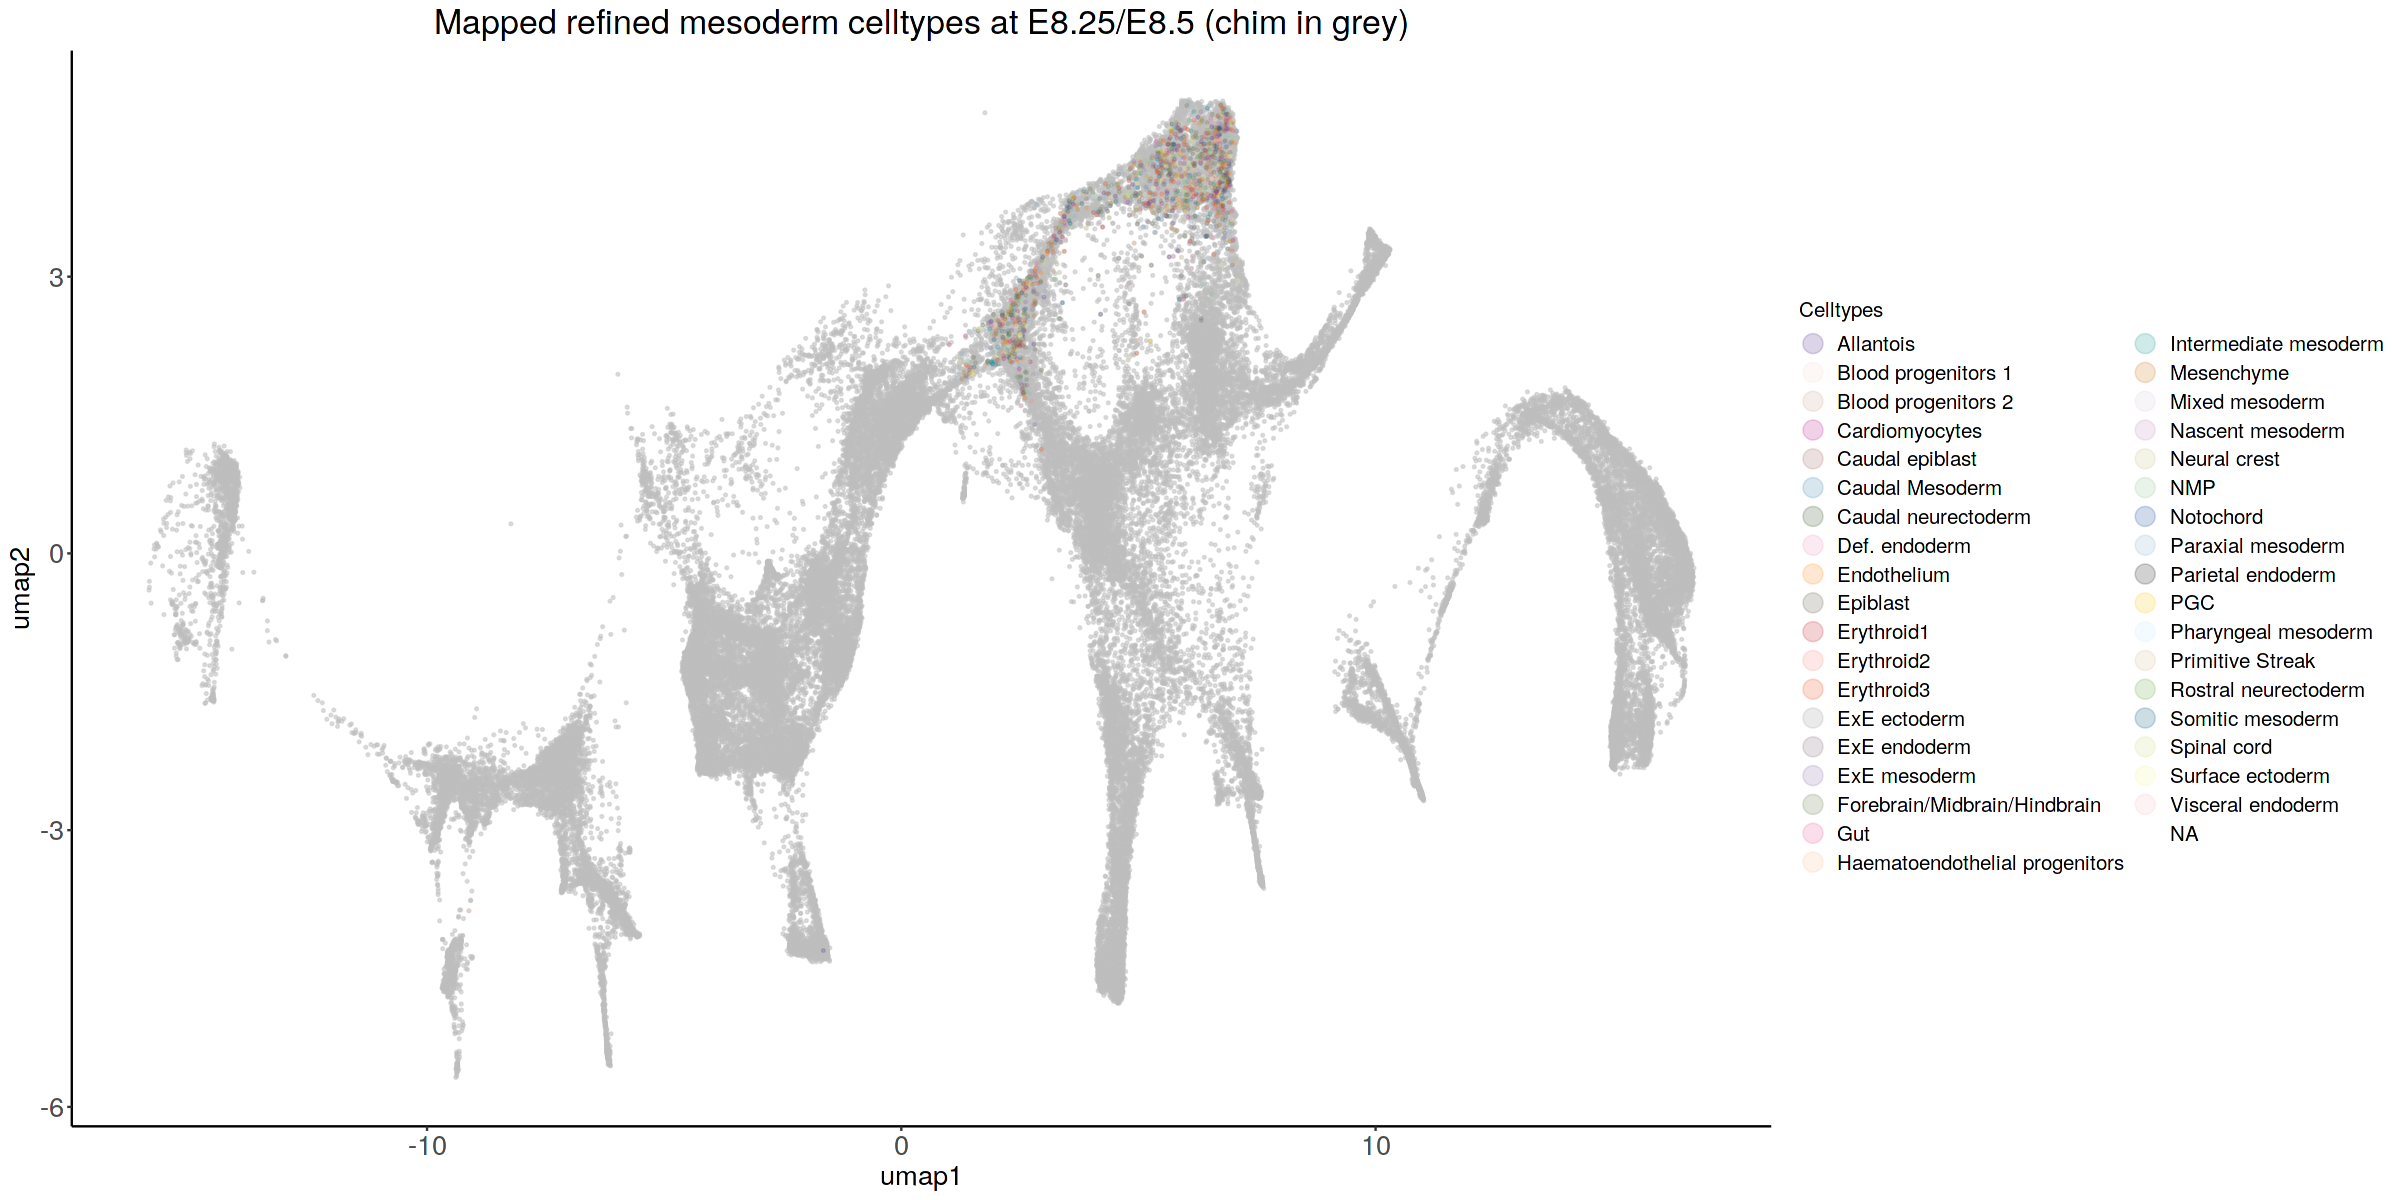

In [91]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

#plot of originally mapped cells now meso.mapped
p1 <- ggplot(big_meta_85, aes(umap1, umap2, color= meso.mapped)) + 
    geom_point(alpha=0.5, size = 0.4, color='grey') +
    geom_point(data=big_meta_85,aes(color=celltype_origin),alpha=0.2, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (chim in grey)') +
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=12)) + 
    theme(legend.title=element_text(size=12)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))


plot_grid(
  p1,
  align = "h", axis = "b", nrow = 1, rel_widths = c(1, 1.7)
)

In [92]:
plot_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/plots/"
png(paste0(plot_folder, "umap_celltype_mapping_meso_original_celltypes.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

Warning message:
“Removed 67887 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 11389 rows containing missing values (geom_point).”


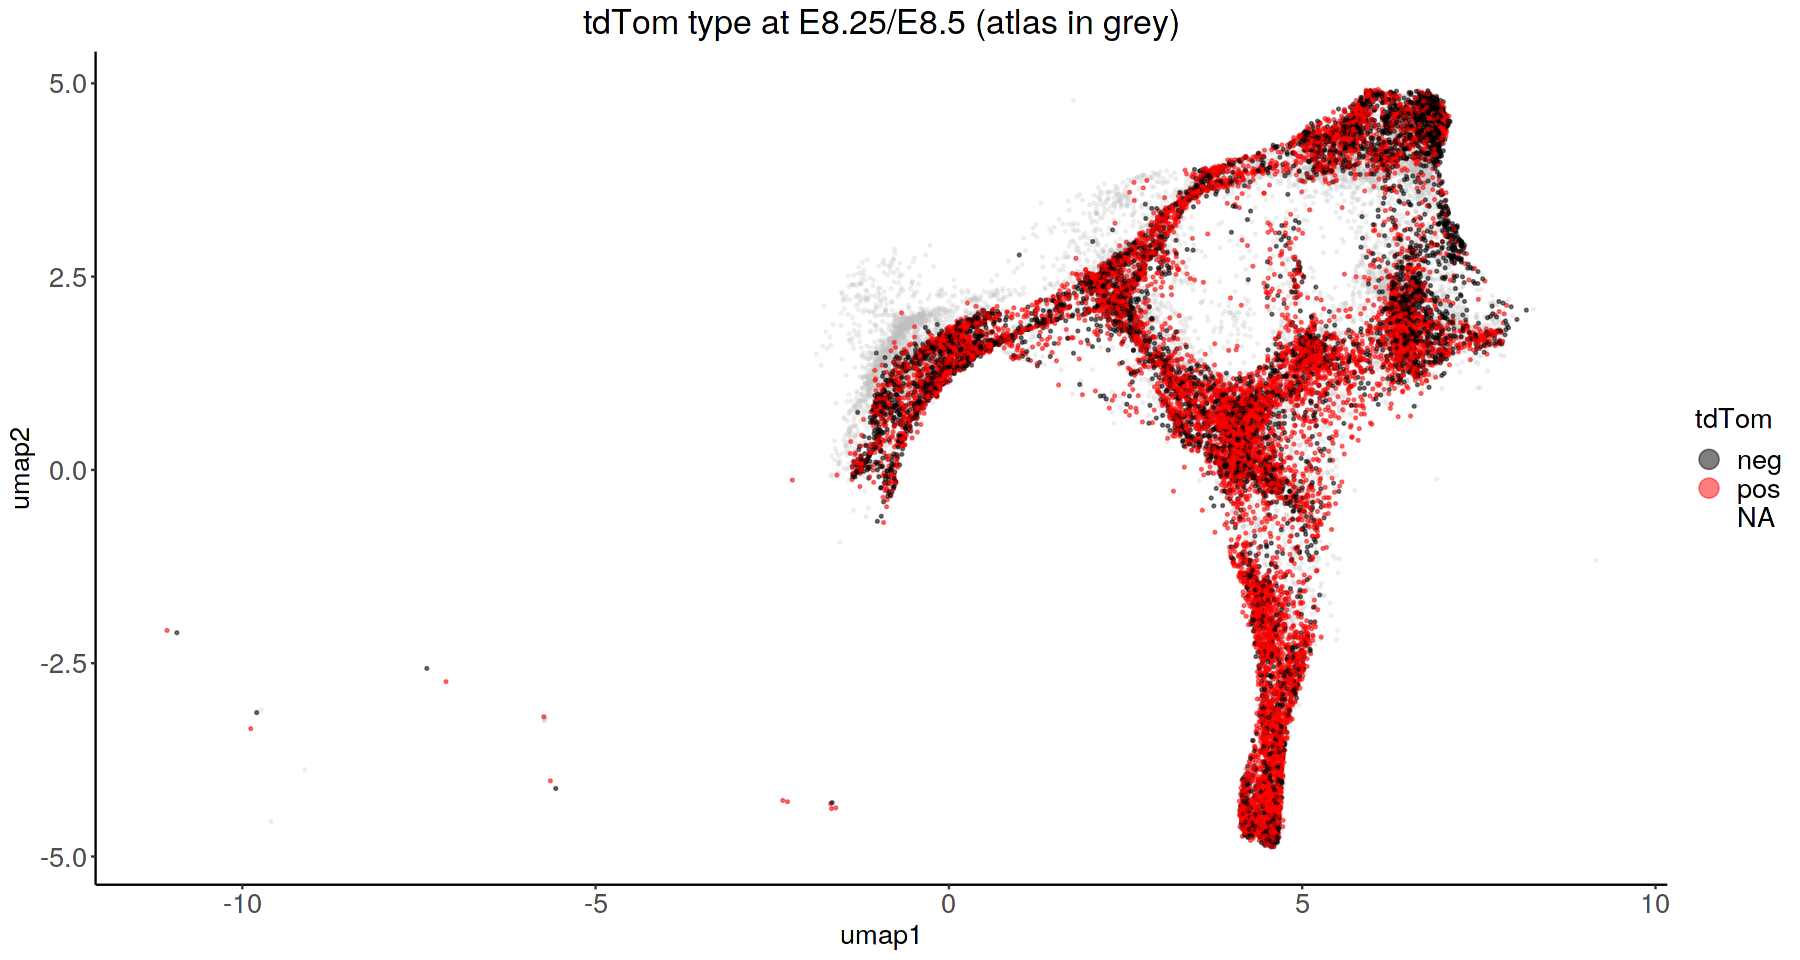

In [93]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")
meso_plot <- big_meta_85 %>% filter(celltype %in% meso | celltype.mapped %in% meso | meso.mapped %in% meso )


p2 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=tdTom),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = c('pos' = 'red', 'neg' = 'black'), labels = c('pos' = 'pos', 'neg' = 'neg')) + 
    ggtitle('tdTom type at E8.25/E8.5 (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(plot.title = element_text(size=20)) +
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p2)

In [94]:
png(paste0(plot_folder, "umap_meso_mapping_dtTOM.png"), height=750, width=900)
    grid.arrange(p2)
dev.off()

Warning message:
“Removed 11389 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 26098 rows containing missing values (geom_point).”


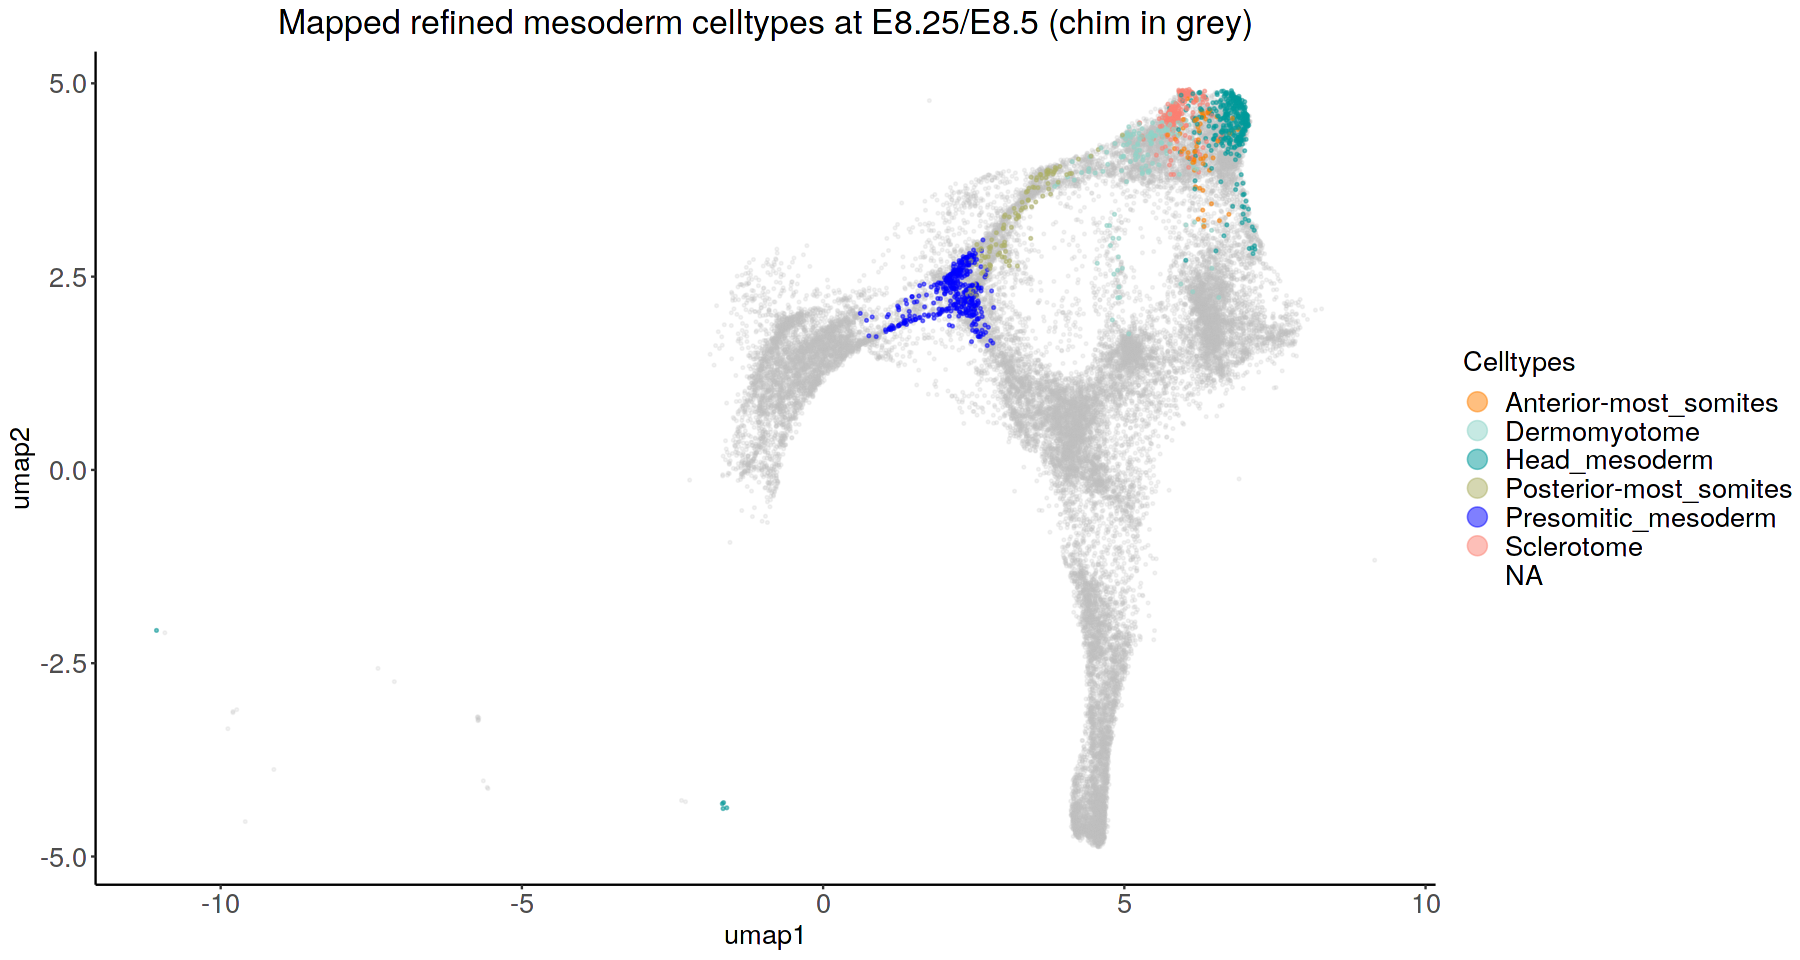

In [95]:
big_meta_85 <- big_meta %>% filter(big_meta$stage %in% c('E8.25','E8.5'))
big_meta_85 <- big_meta_85 %>% filter(big_meta_85$umap2 >= -10)

meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")


meso_plot <- big_meta_85 %>% filter(celltype %in% meso | celltype.mapped %in% meso | meso.mapped %in% meso )
p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=meso.mapped),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped refined mesoderm celltypes at E8.25/E8.5 (chim in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p1)

In [96]:
png(paste0(plot_folder, "umap_meso_mapping_chim_meso-region.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

Warning message:
“Removed 26098 rows containing missing values (geom_point).”


png 
  2

Warning message:
“Removed 11050 rows containing missing values (geom_point).”


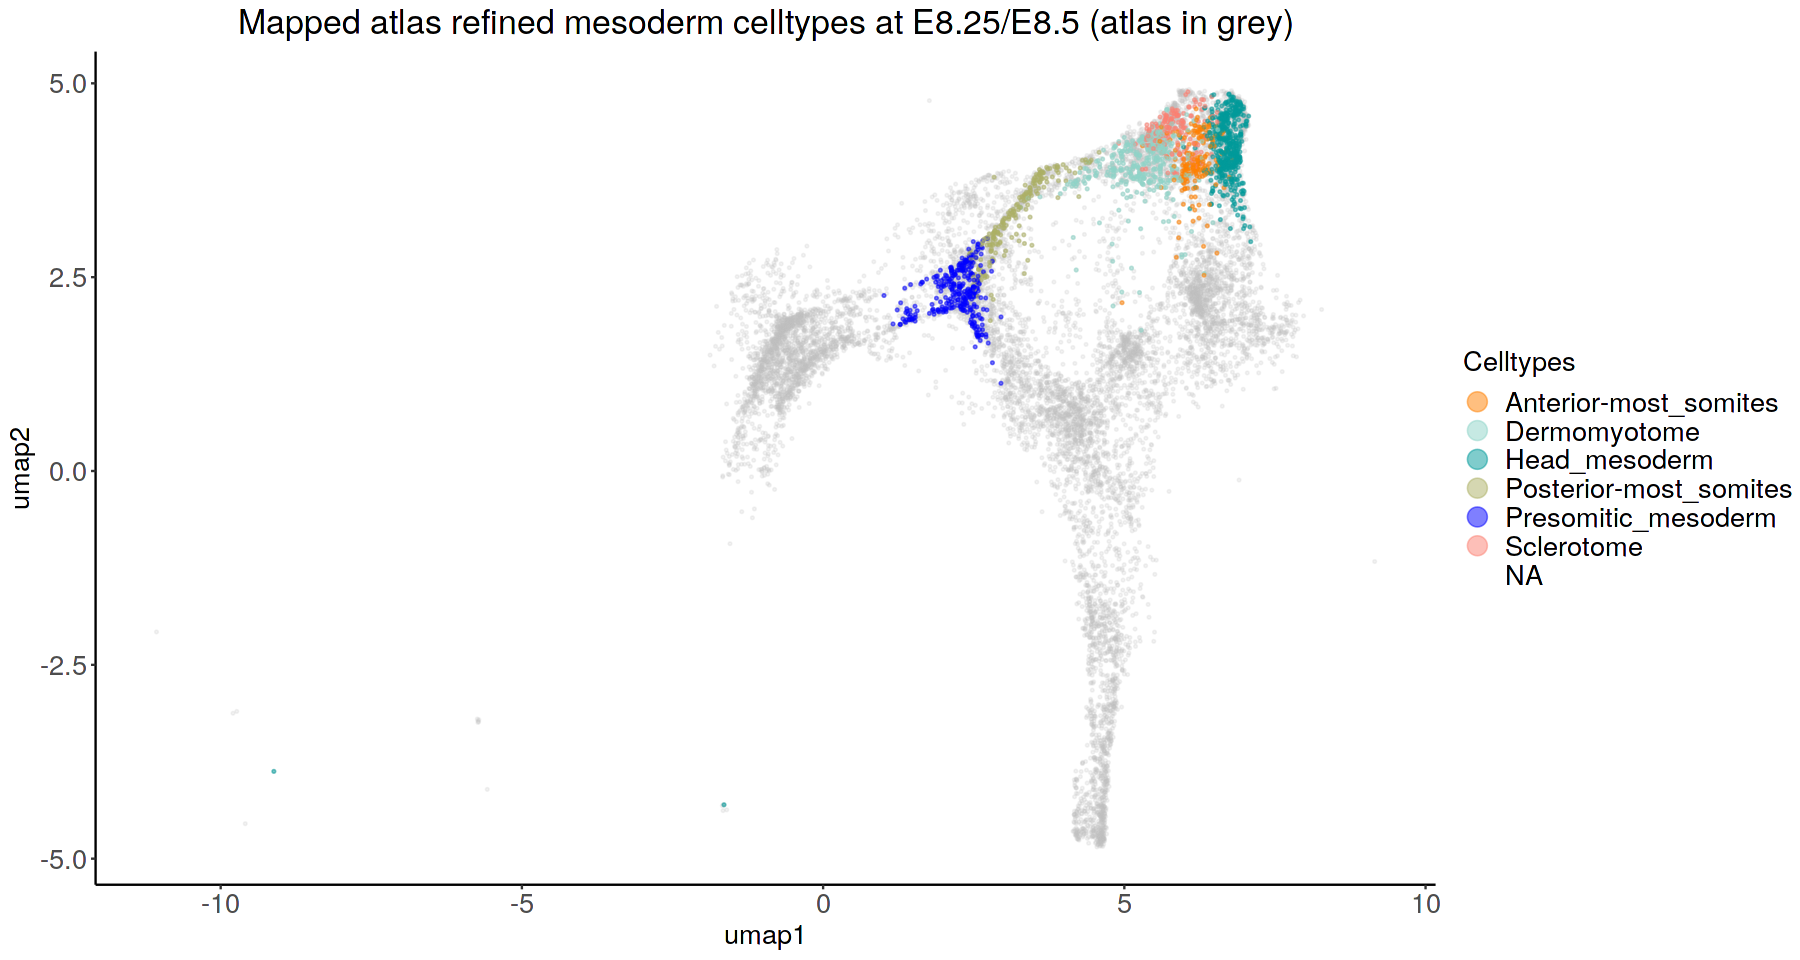

In [97]:
meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP")


meso_plot <- big_meta_85 %>% filter(celltype %in% meso | meso.mapped %in% meso | meso_subcluster %in% meso )


p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=meso_subcluster),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('Mapped atlas refined mesoderm celltypes at E8.25/E8.5 (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p1)

In [98]:
png(paste0(plot_folder, "umap_meso_mapping_atlas.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

Warning message:
“Removed 11050 rows containing missing values (geom_point).”


png 
  2

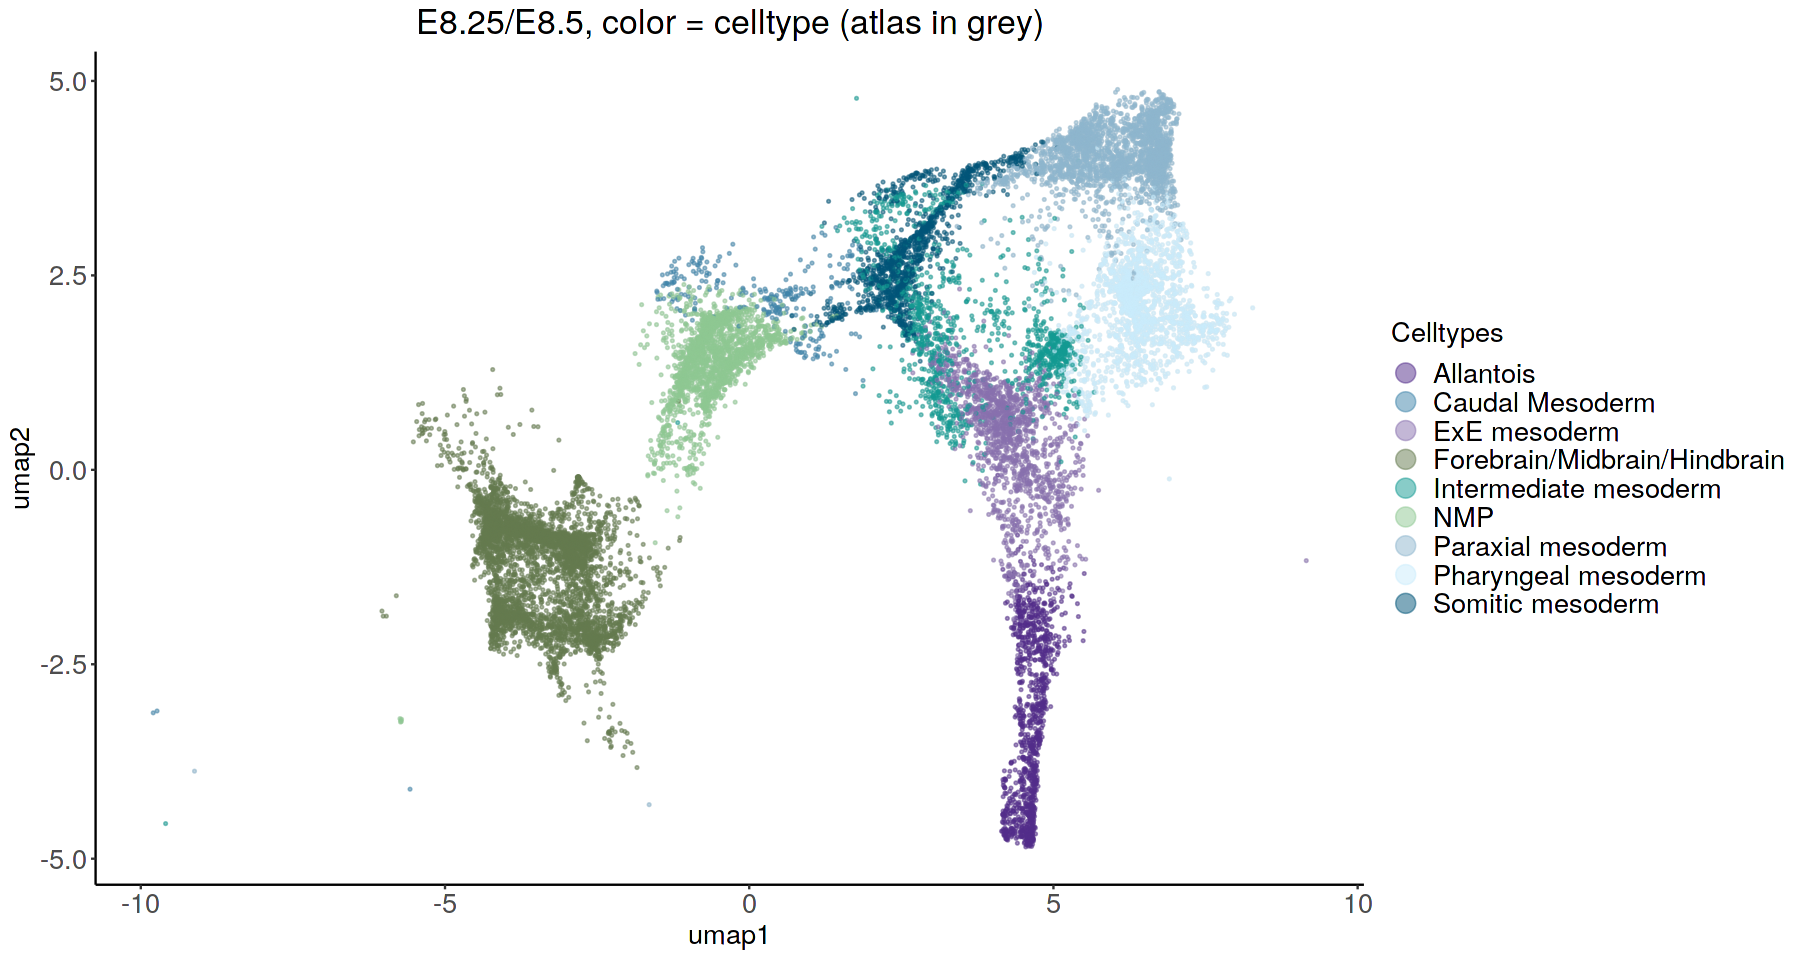

In [99]:
meso <- c("Nascent mesoderm",
                     "Mixed mesoderm",
                     "Intermediate mesoderm",
                     "Caudal Mesoderm",
                     "Paraxial mesoderm",
                     "Somitic mesoderm",
                     "Pharyngeal mesoderm",
                     "Head_mesoderm",
                     "Anterior-most_somites",
                     "Presomitic_mesoderm",
                     "Sclerotome",
                     "Dermomyotome",
                     "Posterior-most_somites",
                     "Allantois",
                     "ExE mesoderm", "NMP",
                     "Forebrain/Midbrain/Hindbrain")


meso_plot <- big_meta_85 %>% filter(celltype %in% meso | celltype_origin %in% meso )


p1 <- ggplot(meso_plot, aes(umap1, umap2)) +
    geom_point(alpha=0.2, size = 0.4, color='grey') +
    geom_point(data=meso_plot,aes(color=celltype),alpha=0.5, size = 0.4) +
    theme_classic() +
    scale_colour_manual(values = celltype_colours, labels = celltype_labels, name = "Celltypes") +
    ggtitle('E8.25/E8.5, color = celltype (atlas in grey)') + 
    guides(colour = guide_legend(override.aes = list(size=5))) +
    theme(plot.title = element_text(hjust = 0.5)) + 
    theme(legend.text=element_text(size=16)) + 
    theme(legend.title=element_text(size=16)) +
    theme(plot.title = element_text(size=20)) +
    theme(axis.text = element_text(size = 16)) +
    theme(axis.title = element_text(size = 16))

options(repr.plot.width = 15, repr.plot.height = 8)
grid.arrange(p1)

In [100]:
png(paste0(plot_folder, "umap_mapping_atlas.png"), height=750, width=1250)
    grid.arrange(p1)
dev.off()

png 
  2

In [166]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "meso.mapped"         "meso_subcluster"     "umap1"              
[37] "umap2"               "celltype_origin"     "origin"

In [165]:
df <- unclass(table(big_meta$celltype.mapped))
df

Allantois      Anterior Primitive Streak 
                          2881                              1 
           Blood progenitors 1            Blood progenitors 2 
                           127                            460 
                Cardiomyocytes                Caudal epiblast 
                          1225                              7 
               Caudal Mesoderm            Caudal neurectoderm 
                           153                              1 
                 Def. endoderm                    Endothelium 
                           444                             22 
                    Erythroid1                     Erythroid2 
                          1141                           2495 
                    Erythroid3                   ExE ectoderm 
                          1518                            167 
                  ExE endoderm                   ExE mesoderm 
                           111                           2977 
  Forebrain/Midbrain/Hindbrain                            Gut 
                          5337                           1102 
Haematoendothelial progenitors          Intermediate mesoderm 
                            19                           1625 
                    Mesenchyme                 Mixed mesoderm 
                           640                              1 
                  Neural crest                            NMP 
                          1407                           2049 
                     Notochord              Paraxial mesoderm 
                            75                           2606 
             Parietal endoderm                            PGC 
                             1                             91 
           Pharyngeal mesoderm           Rostral neurectoderm 
                          2155                             27 
              Somitic mesoderm                    Spinal cord 
                          1621                           1962 
              Surface ectoderm              Visceral endoderm 
                          2713                             47